In [11]:
#Visualiztion

import sys
sys.path.append("..")
from project_package.data_preprocessing import recipes_functions as rf

# Data Cleaning for Recipe Dataset
import pandas as pd
import numpy as np
import re
import os
import kagglehub as kagglehub
import glob

from difflib import SequenceMatcher
from collections import Counter

# see what functions are available
print([name for name in dir(rf) if not name.startswith("_")])

['Counter', 'IngredientNormalizer', 'LossyIngredientReducer', 'PROCESSED_DATA_DIR', 'Path', 'SequenceMatcher', 'add_energy_and_who_flags', 'add_fsa_score', 'add_time_minutes', 'app', 'apply_multiple_thresholds', 'clean_c_columns', 'clean_date_column', 'dataset_summary', 'extract_directions', 'fill_na_with_value', 'flatten_nutrition', 'iso_to_minutes', 'kagglehub', 'logger', 'main', 'np', 'os', 'parse_c_vector', 'pd', 're', 'safe_parse', 'save_in_chunks_by_size', 'tqdm', 'typer']


In [12]:
# path setup
file_path = "../data/processed/Recipes"
file_name = "recipes_chunk_"

# find all matching files
files = sorted(glob.glob(os.path.join(file_path, f"{file_name}*.csv")))

# read and combine
df_recipes = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# check
df_recipes.shape


/var/folders/h7/rdkv64ss4rj67v0yrckxlcdc0000gn/T/ipykernel_26019/3453236233.py:9: DtypeWarning: Columns (2,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recipes = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(572215, 45)

In [13]:
pd.set_option('display.max_columns', None)
df_recipes.head()

,RecipeId,Name,RecipeInstructions,Images,AggregatedRating_na,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,source,PrepTime,CookTime,TotalTime,PrepTime_Minutes,CookTime_Minutes,TotalTime_Minutes,RecipeIngredientParts,RecipeIngredientParts_old,ingredients_canonical,ingredients_canonical_auto,ingredients_canonical_final,ingredients_canonical_final_le_5_replace,EnergyFromFat,EnergyFromSaturatedFat,EnergyFromCarbs,EnergyFromProtein,SaturatedFatPercentEnergy,FatPercentEnergy,WHO_SatFat_Compliant,WHO_Fat_Compliant,WHO_Sodium_Compliant,WHO_Score,WHO_Healthy,Energy_kJ,A_score,C_score,FSA_Score,FSA_Healthy,popularity_score
0,38,Low-Fat Berry Blue Frozen Dessert,"['Toss 2 cups berries with sugar.', 'Let stand...",['https://img.sndimg.com/food/image/upload/w_5...,4.5,4.0,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,foodcom,PT45M,PT24H,PT24H45M,45.0,1440.0,1485.0,"['blueberries', 'granulated sugar', 'vanilla y...","['blueberries', 'granulated sugar', 'vanilla y...","['blueberry', 'sugar', 'vanilla yogurt', 'lemo...","['blueberry', 'sugar', 'vanilla yogurt', 'lemo...","['blueberry', 'sugar', 'vanilla yogurt', 'lemo...","['blueberry', 'sugar', 'vanilla yogurt', 'lemo...",22.5,11.7,148.4,12.8,6.846109,13.165594,True,True,True,3,True,715.0456,9,4,5,False,18.0
1,39,Biryani,['Soak saffron in warm milk for 5 minutes and ...,['https://img.sndimg.com/food/image/upload/w_5...,3.0,1.0,1110.7,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,foodcom,PT4H,PT25M,PT4H25M,240.0,25.0,265.0,"['saffron', 'milk', 'hot green chili peppers',...","['saffron', 'milk', 'hot green chili peppers',...","['saffron', 'milk', 'green chili', 'onion', 'g...","['saffron', 'milk', 'green chili', 'onion', 'g...","['saffron', 'milk', 'green chili', 'onion', 'g...","['saffron', 'milk', 'green chili', 'onion', 'g...",529.2,149.4,337.6,253.6,13.450977,47.645629,False,False,True,1,False,4647.1688,28,10,18,False,3.0
2,40,Best Lemonade,"['Into a 1 quart Jar with tight fitting lid, p...",['https://img.sndimg.com/food/image/upload/w_5...,4.5,10.0,311.1,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,foodcom,PT30M,PT5M,PT35M,30.0,5.0,35.0,"['sugar', 'lemons, rind of', 'lemon, zest of',...","['sugar', 'lemons, rind of', 'lemon, zest of',...","['sugar', 'lemon zest', 'water', 'lemon juice']","['sugar', 'lemon zest', 'water', 'lemon juice']","['sugar', 'lemon zest', 'water', 'lemon juice']","['sugar', 'lemon zest', 'water', 'lemon juice']",1.8,0.0,326.0,1.2,0.000000,0.578592,True,True,True,3,True,1301.6424,13,0,13,False,45.0
3,41,Carina's Tofu-Vegetable Kebabs,"['Drain the tofu, carefully squeezing out exce...",['https://img.sndimg.com/food/image/upload/w_5...,4.5,2.0,536.1,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,foodcom,PT24H,PT20M,PT24H20M,1440.0,20.0,1460.0,"['extra firm tofu', 'eggplant', 'zucchini', 'm...","['extra firm tofu', 'eggplant', 'zucchini', 'm...","['extra tofu', 'eggplant', 'zucchini', 'mushro...","['tofu', 'eggplant', 'zucchini', 'mushroom', '...","['tofu', 'eggplant', 'zucchini', 'mushroom', '...","['tofu', 'eggplant', 'zucchini', 'mushroom', '...",216.0,34.2,256.8,117.2,6.379407,40.290990,True,False,False,1,False,2243.0424,26,10,16,False,9.0
4,42,Cabbage Soup,['Mix everything together and bring to a boil....,[],4.5,11.0,103.6,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,foodcom,PT20M,PT30M,PT50M,20.0,30.0,50.0,"['plain tomato juice', 'cabbage', 'onion', 'ca...","['plain tomato juice', 'cabbage', 'onion', 'ca...","['tomato juice', 'cabbage', 'onion', 'carrot',...","['tomato juice', 'cabbage', 'onion', 'carrot',...","['tomato juice', 'cabbage', 'onion', 'carrot',...","['tomato juice', 'cabbage', 'onion', 'carrot',...",3.6,0.9,100.4,17.2,0.868726,3.474903,True,True,False,2,True,433.4624,14,7,7,False,49.5


In [14]:
df_recipes.columns

Index(['RecipeId', 'Name', 'RecipeInstructions', 'Images',
       'AggregatedRating_na', 'ReviewCount', 'Calories', 'FatContent',
       'SaturatedFatContent', 'CholesterolContent', 'SodiumContent',
       'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent',
       'source', 'PrepTime', 'CookTime', 'TotalTime', 'PrepTime_Minutes',
       'CookTime_Minutes', 'TotalTime_Minutes', 'RecipeIngredientParts',
       'RecipeIngredientParts_old', 'ingredients_canonical',
       'ingredients_canonical_auto', 'ingredients_canonical_final',
       'ingredients_canonical_final_le_5_replace', 'EnergyFromFat',
       'EnergyFromSaturatedFat', 'EnergyFromCarbs', 'EnergyFromProtein',
       'SaturatedFatPercentEnergy', 'FatPercentEnergy', 'WHO_SatFat_Compliant',
       'WHO_Fat_Compliant', 'WHO_Sodium_Compliant', 'WHO_Score', 'WHO_Healthy',
       'Energy_kJ', 'A_score', 'C_score', 'FSA_Score', 'FSA_Healthy',
       'popularity_score'],
      dtype='object')

In [15]:
#Table 1 Basic Statistics of Recipes Dataset 
#Table 2 Distributions of Internet recipes in terms of WHO and FSA health scores.
#Table 3 Top 10 most common ingredients in the recipes dataset.
#Figure 1: Violin plot shows how user perception of the healthiness (1=unhealthy to 7=healthy) varies across Allrecipes.com categories(sorted by highest FSA score (left) to lowest (right)).
#Table 
#Question to answer: RQ1: Determine the Healthiness of Internet Recipes

#Questions to answer: popularity and healthiness of recipes


In [16]:
summary = {}

# total recipes
df_recipes["ID"]= df_recipes["RecipeId"].astype(str) + "_" + df_recipes["source"].astype(str)

#

In [17]:
summary

{}

In [18]:
summary = {
    "Total published recipes": df_recipes["ID"].nunique(),

    "Recipes containing nutrition information": df_recipes[
        ["Calories","FatContent","ProteinContent"]
    ].notna().all(axis=1).sum(),

    "Recipes rated/commented": df_recipes["ReviewCount"].gt(0).sum(),

    "Total ratings/comments": df_recipes["ReviewCount"].sum(),

    "Average rating": df_recipes["AggregatedRating_na"].mean(),

    "Average calories": df_recipes["Calories"].mean(),

    "Average prep time (min)": df_recipes["PrepTime_Minutes"].mean(),

    "Average total time (min)": df_recipes["TotalTime_Minutes"].mean()
}

table1 = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
table1

,Metric,Value
0,Total published recipes,5.722150e+05
1,Recipes containing nutrition information,5.722150e+05
2,Recipes rated/commented,3.247260e+05
3,Total ratings/comments,5.231852e+06
4,Average rating,2.554383e+00
5,Average calories,4.703383e+02
6,Average prep time (min),5.609672e+01
7,Average total time (min),2.545014e+02


In [19]:
# WHO distribution
who_dist = df_recipes["WHO_Healthy"].value_counts().reset_index()
who_dist.columns = ["WHO_Healthy", "Count"]
who_dist["Percent"] = who_dist["Count"] / who_dist["Count"].sum() * 100

# FSA distribution
fsa_dist = df_recipes["FSA_Healthy"].value_counts().reset_index()
fsa_dist.columns = ["FSA_Healthy", "Count"]
fsa_dist["Percent"] = fsa_dist["Count"] / fsa_dist["Count"].sum() * 100

who_dist, fsa_dist

(   WHO_Healthy   Count    Percent
 0        False  360422  62.987164
 1         True  211793  37.012836,
    FSA_Healthy   Count    Percent
 0        False  412993  72.174445
 1         True  159222  27.825555)

In [20]:
table2 = pd.DataFrame({
    "Category": ["Healthy", "Not Healthy"],
    "WHO_Count": [
        (df_recipes["WHO_Healthy"] == 1).sum(),
        (df_recipes["WHO_Healthy"] == 0).sum()
    ],
    "FSA_Count": [
        (df_recipes["FSA_Healthy"] == 1).sum(),
        (df_recipes["FSA_Healthy"] == 0).sum()
    ]
})

# add percentages
table2["WHO_%"] = table2["WHO_Count"] / table2["WHO_Count"].sum() * 100
table2["FSA_%"] = table2["FSA_Count"] / table2["FSA_Count"].sum() * 100

table2

,Category,WHO_Count,FSA_Count,WHO_%,FSA_%
0,Healthy,211793,159222,37.012836,27.825555
1,Not Healthy,360422,412993,62.987164,72.174445


In [21]:
who_table = (
    df_recipes["WHO_Score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

who_table.columns = ["WHO_Score", "Number_of_Recipes"]

who_table

,WHO_Score,Number_of_Recipes
0,0,113996
1,1,246426
2,2,106737
3,3,105056


In [22]:
fsa_table = (
    df_recipes["FSA_Score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fsa_table.columns = ["FSA_Score", "Number_of_Recipes"]

fsa_table

,FSA_Score,Number_of_Recipes
0,-9,79
1,-8,491
2,-7,1079
3,-6,2060
4,-5,3574
5,-4,5754
6,-3,8323
7,-2,11731
8,-1,16434
9,0,31082


In [23]:
who_table = (
    df_recipes["WHO_Score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

who_table.columns = ["WHO_Score", "Number_of_Recipes"]

who_table

,WHO_Score,Number_of_Recipes
0,0,113996
1,1,246426
2,2,106737
3,3,105056


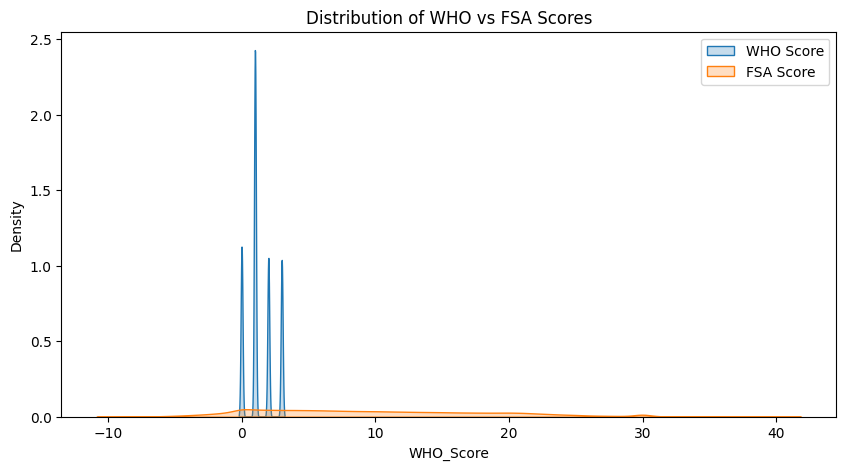

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

sns.kdeplot(df_recipes["WHO_Score"], label="WHO Score", fill=True)
sns.kdeplot(df_recipes["FSA_Score"], label="FSA Score", fill=True)

plt.legend()
plt.title("Distribution of WHO vs FSA Scores")
plt.show()

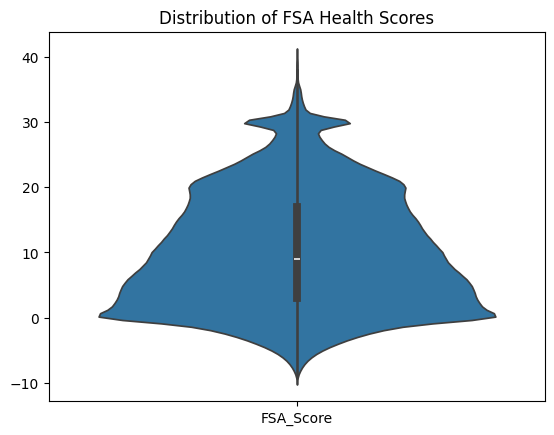

In [25]:
sns.violinplot(data=df_recipes[["FSA_Score"]])
plt.title("Distribution of FSA Health Scores")
plt.show()

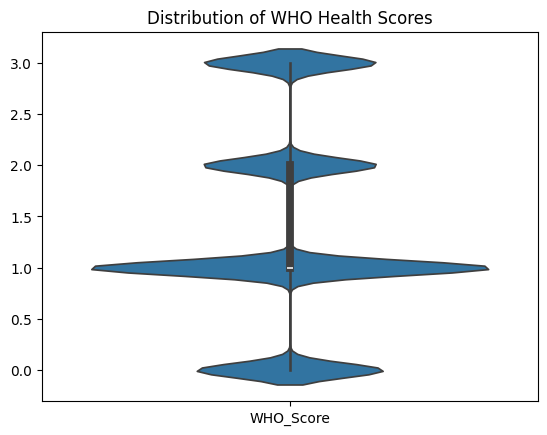

In [26]:
sns.violinplot(data=df_recipes[["WHO_Score"]])
plt.title("Distribution of WHO Health Scores")
plt.show()

In [27]:
df_recipes["WHO_binary"] = df_recipes["WHO_Healthy"]
df_recipes["FSA_binary"] = df_recipes["FSA_Healthy"]

df_recipes["FSA_binned"] = pd.cut(
    df_recipes["FSA_Score"],
    bins=[-10, 0, 5, 10, 40],
    labels=[3, 2, 1, 0]  # 3 = healthiest, 0 = least healthy
)
binary_table = pd.DataFrame({
    "Category": ["Healthy", "Not Healthy"],
    "WHO_Count": [
        (df_recipes["WHO_binary"] == 1).sum(),
        (df_recipes["WHO_binary"] == 0).sum()
    ],
    "FSA_Count": [
        (df_recipes["FSA_binary"] == 1).sum(),
        (df_recipes["FSA_binary"] == 0).sum()
    ]
})

# add percentages
binary_table["WHO_%"] = binary_table["WHO_Count"] / binary_table["WHO_Count"].sum() * 100
binary_table["FSA_%"] = binary_table["FSA_Count"] / binary_table["FSA_Count"].sum() * 100

binary_table

,Category,WHO_Count,FSA_Count,WHO_%,FSA_%
0,Healthy,211793,159222,37.012836,27.825555
1,Not Healthy,360422,412993,62.987164,72.174445


In [28]:
who_dist = df_recipes["WHO_Score"].value_counts().sort_index()
fsa_dist = df_recipes["FSA_binned"].value_counts().sort_index()

binned_table = pd.DataFrame({
    "Level": [0,1,2,3],
    "WHO_Count": who_dist.values,
    "FSA_Count": fsa_dist.values
})

# add percentages
binned_table["WHO_%"] = round(binned_table["WHO_Count"] / binned_table["WHO_Count"].sum() * 100,0)
binned_table["FSA_%"] = round(binned_table["FSA_Count"] / binned_table["FSA_Count"].sum() * 100,0)

binned_table

,Level,WHO_Count,FSA_Count,WHO_%,FSA_%
0,0,113996,80607,20.0,14.0
1,1,246426,128884,43.0,23.0
2,2,106737,111097,19.0,19.0
3,3,105056,251627,18.0,44.0


In [29]:
from collections import Counter
import ast
import pandas as pd

# --- convert columns to list ---

# old ingredients
df_recipes["ingredients_old_list"] = df_recipes["RecipeIngredientParts_old"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# final ingredients
df_recipes["ingredients_final_list"] = df_recipes["ingredients_canonical_final"].apply(
    lambda x: x.split("^") if isinstance(x, str) and x != "" else []
)

# --- count ingredients ---

# OLD
old_counter = Counter()
for items in df_recipes["ingredients_old_list"]:
    old_counter.update(items)

# FINAL
final_counter = Counter()
for items in df_recipes["ingredients_final_list"]:
    final_counter.update(items)

# --- convert to dataframe ---

old_df = pd.DataFrame(old_counter.items(), columns=["Ingredient", "Count"]).sort_values(by="Count", ascending=False)

final_df = pd.DataFrame(final_counter.items(), columns=["Ingredient", "Count"]).sort_values(by="Count", ascending=False)

# view top 20
old_df.head(20), final_df.head(20)

(            Ingredient   Count
 20                salt  214795
 51              butter  149133
 29               sugar  116450
 54               water   91588
 22               onion   91364
 28                eggs   86942
 39           olive oil   84184
 5                 milk   67306
 59               flour   62642
 43       garlic cloves   59740
 91   all-purpose flour   53912
 113             pepper   50164
 70         brown sugar   45527
 8               garlic   43787
 73       baking powder   43447
 66                 egg   43315
 92         baking soda   36696
 3          lemon juice   34980
 53     vanilla extract   34253
 74             vanilla   33361,
                                              Ingredient  Count
 90                                                   []  10891
 710                                  ['sugar', 'water']    116
 15787                                  ['egg', 'water']    107
 243                                  ['water', 'sugar']    104
 8032  

In [30]:
from collections import Counter
import ast
import pandas as pd

counter = Counter()

for items in df_recipes["ingredients_canonical_final_le_5_replace"].dropna():
    try:
        # convert string → list
        ingredients = ast.literal_eval(items)

        # count each ingredient separately
        counter.update(ingredients)

    except:
        continue

# convert to dataframe
ingredient_df = pd.DataFrame(
    counter.items(),
    columns=["Ingredient", "Count"]
).sort_values(by="Count", ascending=False)

ingredient_df.head(20)

,Ingredient,Count
19,salt,207585
7,onion,147344
1,sugar,136805
45,butter,135578
8,garlic,131991
26,egg,131107
34,olive oil,97292
28,water,86916
5,milk,73294
51,flour,59313


In [31]:
old_df

,Ingredient,Count
20,salt,214795
51,butter,149133
29,sugar,116450
54,water,91588
22,onion,91364
...,...,...
22675,x 13 inch) pan cornbread crumbled,1
22673,chinese cooking wine divided,1
22672,fresh ginger root finely chopped divided,1
22671,oyster sauce divided,1


In [32]:
#ingredient_df.to_csv("data/processed/ingredient_counts_ingredients_canonical_final_le_5_replace.csv", index=False)

In [33]:
ingredient_df

,Ingredient,Count
19,salt,207585
7,onion,147344
1,sugar,136805
45,butter,135578
8,garlic,131991
...,...,...
4183,torn arugula leaf,6
429,olive oil flavored vegetable cooking spray,6
4181,mccormick garlic powder,6
4172,fluid ounce whiskey,6


In [34]:
#top recipes that contains ingredients with high counts
from collections import defaultdict
import ast
import pandas as pd

ingredient_ids = defaultdict(set)

for _, row in df_recipes.iterrows():
    recipe_id = row["ID"]
    items = row["ingredients_canonical_final_le_5_replace"]

    try:
        ingredients = ast.literal_eval(items) if isinstance(items, str) else []
        
        for ing in ingredients:
            ingredient_ids[ing].add(recipe_id)

    except:
        continue

In [35]:
ingredient_table = pd.DataFrame({
    "Ingredient": list(ingredient_ids.keys()),
    "Count": [len(v) for v in ingredient_ids.values()],
    "IDs": [list(v)[:10] for v in ingredient_ids.values()]  # show first 10 IDs only
}).sort_values(by="Count", ascending=False)

ingredient_table

,Ingredient,Count,IDs
19,salt,207585,"[477147_foodcom, 358027_foodcom, 236626_foodre..."
7,onion,147344,"[236626_foodrecsys, 436539_foodcom, 441185_foo..."
1,sugar,136805,"[358027_foodcom, 58770_foodcom, 36355_foodrecs..."
45,butter,135578,"[297075_foodcom, 358027_foodcom, 10095_foodrec..."
8,garlic,131991,"[19919_foodrecsys, 477147_foodcom, 447625_food..."
...,...,...,...
4183,torn arugula leaf,6,"[57955_foodrecsys, 81026_foodrecsys, 241562_fo..."
429,olive oil flavored vegetable cooking spray,6,"[3529_foodcom, 414821_foodcom, 296082_foodcom,..."
4181,mccormick garlic powder,6,"[235413_foodrecsys, 241572_foodrecsys, 219118_..."
4172,fluid ounce whiskey,6,"[153120_foodrecsys, 256262_foodrecsys, 229196_..."


In [36]:
from collections import Counter
import ast

counter = Counter()

for items in df_recipes["ingredients_canonical_final_le_5_replace"].dropna():
    try:
        ingredients = ast.literal_eval(items)
        counter.update(ingredients)
    except:
        continue

top200 = set([i[0] for i in counter.most_common(200)])

In [37]:
recipe_counts = []

for _, row in df_recipes.iterrows():
    recipe_id = row["ID"]
    
    try:
        ingredients = set(ast.literal_eval(row["ingredients_canonical_final_le_5_replace"]))
        count = len(ingredients & top200)
        
        recipe_counts.append({
            "ID": recipe_id,
            "Name": row["Name"],
            "Top200_Ingredient_Count": count,
            "URL": row["Images"],  # or RecipeURL if you have it
            "FSA_Healthy": row["FSA_Healthy"],  # or FSA_Healthy
            "WHO_Healthy": row["WHO_Healthy"],  # or FSA_Healthy
            "popularity": row["popularity_score"]  # or AggregatedRating_na
        })
        
    except:
        continue

In [38]:
recipe_df = pd.DataFrame(recipe_counts)

top_recipes = recipe_df.sort_values(
    by="Top200_Ingredient_Count",
    ascending=False
)
pd.set_option('display.max_colwidth', None)
top_recipes

,ID,Name,Top200_Ingredient_Count,URL,FSA_Healthy,WHO_Healthy,popularity
2236,3748_foodcom,A-To-Z Bread,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/4h615IdTQaKXephz0pgy-a_to_z_bread1.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/7dfL1fCJTvuBI6C11Of4_PSX_20161127_155220.jpg']",False,True,110.0
514536,533159_foodcom,Marinated Pork Tortas With Cilantro Aioli &amp; Chiles Curtidos,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/uPEjeG2RQoqam3ilu5S3_0268807_GK_American-Dinner-300_Main-Episode_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/ebY3pRwsTBS99tx6aW5M_0268807_GK_American-Dinner-300_Main-Episode_4x3_V7_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/F2dZScyS7SB270EIGlF5_0268807_GK_American-Dinner-300_Main-Episode_4x3_V3_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/hEAere1PRCOC3yh0cCaZ_0268807_GK_American-Dinner-300_Main-Episode_4x3_V6_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/O5i4CFo2QHqWVZP3yHJ8_0268807_GK_American-Dinner-300_Main-Episode_4x3_V5_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/HN2Khj4OQqztyXZSHx2W_0268807_GK_American-Dinner-300_Main-Episode_4x3_V4_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/RuTRcAlRFuVV4nA9G3SP_0268807_GK_American-Dinner-300_Main-Episode_4x3_V2_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/f4a3lF6qRTGlSGeSLR4Z_0268807_GK_American-Dinner-300_Main-Episode_Cooking_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/7F0M65pQaCRnWiGNmWK8_0268807_GK_American-Dinner-300_Main-Episode_Eduardo-Rivera_4x3_V2_V.jpg']",False,False,0.0
318812,330943_foodcom,Sopa Espanola (Spanish Soup),28,[],False,False,0.0
263508,274095_foodcom,Spicy Idaho Potato and Chicken Croquettes,27,[],False,False,0.0
90844,96145_foodcom,Schmackhaft German Salad,27,[],False,True,0.0
...,...,...,...,...,...,...,...
210602,219686_foodcom,Espresso Martini,0,[],True,True,0.0
210607,219691_foodcom,Apple Cider Syrup,0,[],True,True,5.0
210620,219705_foodcom,Oatmeal Cookie Shot,0,[],True,False,30.0
210626,219711_foodcom,Cajun Rattlesnake,0,[],False,True,25.0


In [39]:
top_recipes = top_recipes[top_recipes["URL"] != "[]"]

In [40]:
top_recipes



,ID,Name,Top200_Ingredient_Count,URL,FSA_Healthy,WHO_Healthy,popularity
2236,3748_foodcom,A-To-Z Bread,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/4h615IdTQaKXephz0pgy-a_to_z_bread1.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/7dfL1fCJTvuBI6C11Of4_PSX_20161127_155220.jpg']",False,True,110.0
514536,533159_foodcom,Marinated Pork Tortas With Cilantro Aioli &amp; Chiles Curtidos,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/uPEjeG2RQoqam3ilu5S3_0268807_GK_American-Dinner-300_Main-Episode_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/ebY3pRwsTBS99tx6aW5M_0268807_GK_American-Dinner-300_Main-Episode_4x3_V7_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/F2dZScyS7SB270EIGlF5_0268807_GK_American-Dinner-300_Main-Episode_4x3_V3_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/hEAere1PRCOC3yh0cCaZ_0268807_GK_American-Dinner-300_Main-Episode_4x3_V6_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/O5i4CFo2QHqWVZP3yHJ8_0268807_GK_American-Dinner-300_Main-Episode_4x3_V5_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/HN2Khj4OQqztyXZSHx2W_0268807_GK_American-Dinner-300_Main-Episode_4x3_V4_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/RuTRcAlRFuVV4nA9G3SP_0268807_GK_American-Dinner-300_Main-Episode_4x3_V2_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/f4a3lF6qRTGlSGeSLR4Z_0268807_GK_American-Dinner-300_Main-Episode_Cooking_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/7F0M65pQaCRnWiGNmWK8_0268807_GK_American-Dinner-300_Main-Episode_Eduardo-Rivera_4x3_V2_V.jpg']",False,False,0.0
487061,505050_foodcom,North African Meatballs (Boulettes),27,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/er5ouPyNQH6jH7sRGjnp-IMG_1052.JPG', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/picf6v6VI.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/picDyuy1J.jpg']",False,False,25.0
374465,388000_foodcom,BBQ Pork Sandwich on Grilled Jalapeno Corn Flat Bread,25,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/I3qgcpw4RH6jiY1sfaz8_B9FA3333-955C-4940-8CED-AD75882EDCAD.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/KNrNXCDbSM2diG0oaULa_553CBE11-A9C1-4E13-AC35-4276F638ED34.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/IrS03AzQTtuD4agaetp5_83400E4C-1E20-4BBA-B9B3-52584815E7A3.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/K3lWkfqsRfq6l3B3u1jc_D2A03B10-E724-44FC-A196-C1CC254F2E37.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/bXKeOHgkQKeYP9ke2eIK_1ECA5C2B-19F4-422E-89CF-037126E06937.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/OUhfIpOkSHqO7fq5KUvE_AD2BB504-851E-4B99-8E9C-F46A6CD099F6.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/hB1QdD6mQGe6iH2X6ZTc_2C796DDA-DA69-4E91-B7A1-A258C02EB811.jpeg']",False,False,5.0
421635,437161_foodcom,Vegetarian Chili(Emeril Lagasse),

In [44]:
top_recipes.shape

(132984, 7)

In [49]:
top_recipes

,ID,Name,Top200_Ingredient_Count,URL,FSA_Healthy,WHO_Healthy,popularity
2236,3748_foodcom,A-To-Z Bread,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/4h615IdTQaKXephz0pgy-a_to_z_bread1.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/37/48/7dfL1fCJTvuBI6C11Of4_PSX_20161127_155220.jpg']",False,True,110.0
514536,533159_foodcom,Marinated Pork Tortas With Cilantro Aioli &amp; Chiles Curtidos,28,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/uPEjeG2RQoqam3ilu5S3_0268807_GK_American-Dinner-300_Main-Episode_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/ebY3pRwsTBS99tx6aW5M_0268807_GK_American-Dinner-300_Main-Episode_4x3_V7_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/F2dZScyS7SB270EIGlF5_0268807_GK_American-Dinner-300_Main-Episode_4x3_V3_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/hEAere1PRCOC3yh0cCaZ_0268807_GK_American-Dinner-300_Main-Episode_4x3_V6_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/O5i4CFo2QHqWVZP3yHJ8_0268807_GK_American-Dinner-300_Main-Episode_4x3_V5_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/HN2Khj4OQqztyXZSHx2W_0268807_GK_American-Dinner-300_Main-Episode_4x3_V4_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/RuTRcAlRFuVV4nA9G3SP_0268807_GK_American-Dinner-300_Main-Episode_4x3_V2_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/f4a3lF6qRTGlSGeSLR4Z_0268807_GK_American-Dinner-300_Main-Episode_Cooking_4x3_V1_H.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/53/31/59/7F0M65pQaCRnWiGNmWK8_0268807_GK_American-Dinner-300_Main-Episode_Eduardo-Rivera_4x3_V2_V.jpg']",False,False,0.0
487061,505050_foodcom,North African Meatballs (Boulettes),27,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/er5ouPyNQH6jH7sRGjnp-IMG_1052.JPG', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/picf6v6VI.jpg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/50/50/50/picDyuy1J.jpg']",False,False,25.0
374465,388000_foodcom,BBQ Pork Sandwich on Grilled Jalapeno Corn Flat Bread,25,"['https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/I3qgcpw4RH6jiY1sfaz8_B9FA3333-955C-4940-8CED-AD75882EDCAD.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/KNrNXCDbSM2diG0oaULa_553CBE11-A9C1-4E13-AC35-4276F638ED34.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/IrS03AzQTtuD4agaetp5_83400E4C-1E20-4BBA-B9B3-52584815E7A3.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/K3lWkfqsRfq6l3B3u1jc_D2A03B10-E724-44FC-A196-C1CC254F2E37.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/bXKeOHgkQKeYP9ke2eIK_1ECA5C2B-19F4-422E-89CF-037126E06937.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/OUhfIpOkSHqO7fq5KUvE_AD2BB504-851E-4B99-8E9C-F46A6CD099F6.jpeg', 'https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/80/00/hB1QdD6mQGe6iH2X6ZTc_2C796DDA-DA69-4E91-B7A1-A258C02EB811.jpeg']",False,False,5.0
421635,437161_foodcom,Vegetarian Chili(Emeril Lagasse),

In [66]:
import pandas as pd
import ast
import altair as alt

# -----------------------------------
# 1. start from df_recipes
# -----------------------------------
df = df_recipes.copy()

# -----------------------------------
# 2. parse ingredient column
#    handles:
#    - python-list-like strings: "['milk', 'sugar']"
#    - caret-separated strings: "milk^sugar"
#    - actual python lists
# -----------------------------------
def parse_ingredients(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return [str(i).strip().lower() for i in x if str(i).strip()]

    if isinstance(x, str):
        x = x.strip()

        if x == "":
            return []

        # case 1: string representation of list
        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return [str(i).strip().lower() for i in parsed if str(i).strip()]
            except Exception:
                pass

        # case 2: caret-separated string
        if "^" in x:
            return [i.strip().lower() for i in x.split("^") if i.strip()]

        # case 3: single ingredient string
        return [x.lower()]

    return []

df["ingredients_list"] = df["ingredients_canonical_final_le_5_replace"].apply(parse_ingredients)

# -----------------------------------
# 3. explode to one row per ingredient
# -----------------------------------
df_exploded = df.explode("ingredients_list").copy()
df_exploded = df_exploded.rename(columns={"ingredients_list": "ingredient"})

# -----------------------------------
# 4. clean ingredient text
# -----------------------------------
df_exploded["ingredient"] = (
    df_exploded["ingredient"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# remove bad rows
bad_values = {"", "nan", "none", "[]", "['']", '[""]'}
df_exploded = df_exploded[
    df_exploded["ingredient"].notna() &
    (~df_exploded["ingredient"].isin(bad_values))
].copy()

# -----------------------------------
# 5. remove spice-like ingredients
#    if ingredient is close to spices, treat as spice
#    here implemented with keyword containment
# -----------------------------------
spice_keywords = [
    "salt", "pepper", "black pepper", "white pepper",
    "garlic powder", "onion powder", "paprika", "cumin",
    "oregano", "basil", "thyme", "parsley", "chili powder",
    "chili", "cinnamon", "nutmeg", "clove", "ginger",
    "turmeric", "seasoning", "spice", "herb", "rosemary",
    "sage", "coriander", "cilantro", "bay leaf", "cardamom",
    "allspice", "dill", "mint", "tarragon", "marjoram"
]

def is_spice(ingredient):
    ingredient = str(ingredient).lower()
    return any(spice in ingredient for spice in spice_keywords)

df_exploded["is_spice"] = df_exploded["ingredient"].apply(is_spice)

# keep non-spice ingredients only
df_clean = df_exploded[~df_exploded["is_spice"]].copy()

# -----------------------------------
# 6. aggregate to single-ingredient statistics
# -----------------------------------
ingredient_stats = (
    df_clean
    .groupby("ingredient")
    .agg(
        avg_WHO_score=("WHO_Score", "mean"),
        avg_FSA_score=("FSA_Score", "mean"),
        avg_popularity_score=("popularity_score", "mean"),
        recipe_count=("ingredient", "count")
    )
    .reset_index()
)

# -----------------------------------
# 7. optional: filter low-frequency ingredients
# -----------------------------------
min_count = 20
ingredient_stats = ingredient_stats[
    ingredient_stats["recipe_count"] >= min_count
].copy()

# -----------------------------------
# 8. sort results
# -----------------------------------
ingredient_stats = ingredient_stats.sort_values(
    by="recipe_count",
    ascending=False
).reset_index(drop=True)

# -----------------------------------
# 9. preview result
# -----------------------------------
print("Single-ingredient stats:")
print(ingredient_stats.head(20))

# -----------------------------------
# 10. quick checks
# -----------------------------------
print("\nExploded ingredient sample:")
print(df_clean["ingredient"].head(20).tolist())

print("\nNumber of unique ingredients:")
print(ingredient_stats["ingredient"].nunique())

# -----------------------------------
# 11. plot: WHO vs popularity
# -----------------------------------
chart = alt.Chart(ingredient_stats).mark_circle(size=80).encode(
    x=alt.X("avg_WHO_score:Q", title="Average WHO Score"),
    y=alt.Y("avg_popularity_score:Q", title="Average Popularity Score"),
    size=alt.Size("recipe_count:Q", title="Recipe Count"),
    color=alt.Color("avg_FSA_score:Q", title="Average FSA Score"),
    tooltip=[
        alt.Tooltip("ingredient:N", title="Ingredient"),
        alt.Tooltip("avg_WHO_score:Q", title="Avg WHO", format=".2f"),
        alt.Tooltip("avg_FSA_score:Q", title="Avg FSA", format=".2f"),
        alt.Tooltip("avg_popularity_score:Q", title="Avg Popularity", format=".3f"),
        alt.Tooltip("recipe_count:Q", title="Recipe Count")
    ]
).properties(
    title="Ingredient-Level Average Health and Popularity Scores"
)

chart

Single-ingredient stats:
           ingredient  avg_WHO_score  avg_FSA_score  avg_popularity_score  \
0               onion       1.200680       9.525064             42.702364   
1               sugar       1.478396      12.617170             53.847954   
2              butter       0.938604      13.744708             56.406104   
3              garlic       1.268988       9.164413             40.561883   
4                 egg       1.139611      12.661162             47.358180   
5           olive oil       1.353133       7.846411             35.656593   
6               water       1.529615       9.994892             41.220870   
7                milk       1.170778      12.235094             51.806787   
8               flour       1.192049      13.107953             17.972652   
9         brown sugar       1.360500      13.279262             56.485282   
10  all purpose flour       1.254506      12.066505            109.036250   
11        lemon juice       1.480293       9.547583

alt.Chart(...)

In [81]:
import pandas as pd
import ast
import altair as alt
import numpy as np

alt.data_transformers.disable_max_rows()

# -----------------------------------
# 1. start from df_recipes
# -----------------------------------
df = df_recipes.copy()

# -----------------------------------
# 2. parse ingredients
# -----------------------------------
def parse_ingredients(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(i).strip().lower() for i in x if str(i).strip()]
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return [str(i).strip().lower() for i in parsed if str(i).strip()]
            except Exception:
                pass
        if "^" in x:
            return [i.strip().lower() for i in x.split("^") if i.strip()]
        return [x.lower()]
    return []

df["ingredients_list"] = df["ingredients_canonical_final_le_5_replace"].apply(parse_ingredients)

# -----------------------------------
# 3. explode to one row per ingredient
# -----------------------------------
df_exploded = df.explode("ingredients_list").copy()
df_exploded = df_exploded.rename(columns={"ingredients_list": "ingredient"})

df_exploded["ingredient"] = (
    df_exploded["ingredient"]
    .astype(str)
    .str.strip()
    .str.lower()
)

bad_values = {"", "nan", "none", "[]", "['']", '[""]'}
df_exploded = df_exploded[
    df_exploded["ingredient"].notna() &
    (~df_exploded["ingredient"].isin(bad_values))
].copy()

# -----------------------------------
# 4. remove spice-like ingredients
# -----------------------------------
spice_keywords = [
    "salt", "pepper", "black pepper", "white pepper",
    "garlic powder", "onion powder", "paprika", "cumin",
    "oregano", "basil", "thyme", "parsley", "chili powder",
    "chili", "cinnamon", "nutmeg", "clove", "ginger",
    "turmeric", "seasoning", "spice", "herb", "rosemary",
    "sage", "coriander", "cilantro", "bay leaf", "cardamom",
    "allspice", "dill", "mint", "tarragon", "marjoram","other_target_ingredient",
]

def is_spice(ingredient):
    ingredient = str(ingredient).lower()
    return any(spice in ingredient for spice in spice_keywords)

df_clean = df_exploded[~df_exploded["ingredient"].apply(is_spice)].copy()

# -----------------------------------
# 5. aggregate ingredient-level metrics
# -----------------------------------
ingredient_stats = (
    df_clean
    .groupby("ingredient")
    .agg(
        avg_FSA_score=("FSA_Score", "mean"),
        avg_popularity_score=("popularity_score", "mean"),
        recipe_count=("ingredient", "count")
    )
    .reset_index()
)

ingredient_stats = ingredient_stats[
    ingredient_stats["recipe_count"] >= 20
].copy()

# -----------------------------------
# 6. define healthy vs not healthy
#    lower FSA score = healthier
# -----------------------------------
fsa_threshold = 6

ingredient_stats["FSA_health_label"] = np.where(
    ingredient_stats["avg_FSA_score"] <= fsa_threshold,
    "Healthy",
    "Not Healthy"
)

# -----------------------------------
# 7. keep top N for cleaner dropdown
# -----------------------------------
top_n = 100
ingredient_stats = (
    ingredient_stats
    .sort_values("recipe_count", ascending=False)
    .head(top_n)
    .copy()
)

ingredient_list = sorted(ingredient_stats["ingredient"].tolist())
ingredient_options = ["All"] + ingredient_list

# regular parameter, not selection_point
ingredient_param = alt.param(
    name="ingredient_select",
    value="All",
    bind=alt.binding_select(
        options=ingredient_options,
        name="Select ingredient: "
    )
)

# -----------------------------------
# 8. base scatter plot
# -----------------------------------
base = alt.Chart(ingredient_stats).encode(
    x=alt.X("avg_FSA_score:Q", title="Average FSA Score"),
    y=alt.Y("avg_popularity_score:Q", title="Average Popularity Score"),
    size=alt.Size("recipe_count:Q", title="Recipe Count"),
    tooltip=[
        alt.Tooltip("ingredient:N", title="Ingredient"),
        alt.Tooltip("avg_FSA_score:Q", title="Avg FSA Score", format=".2f"),
        alt.Tooltip("avg_popularity_score:Q", title="Avg Popularity Score", format=".3f"),
        alt.Tooltip("recipe_count:Q", title="Recipe Count"),
        alt.Tooltip("FSA_health_label:N", title="FSA Health Status")
    ]
)

# -----------------------------------
# 9. all points colored by healthy / not healthy
# -----------------------------------
all_points = base.mark_circle(opacity=0.75).encode(
    color=alt.Color(
        "FSA_health_label:N",
        title="FSA Health Status"
    )
)

# -----------------------------------
# 10. highlight selected ingredient
#      show only if dropdown != All
# -----------------------------------
highlight_point = (
    alt.Chart(ingredient_stats)
    .transform_filter("ingredient_select != 'All' && datum.ingredient == ingredient_select")
    .mark_circle(size=350, stroke="black", strokeWidth=2, filled=False)
    .encode(
        x="avg_FSA_score:Q",
        y="avg_popularity_score:Q",
        tooltip=[
            alt.Tooltip("ingredient:N", title="Ingredient"),
            alt.Tooltip("avg_FSA_score:Q", title="Avg FSA Score", format=".2f"),
            alt.Tooltip("avg_popularity_score:Q", title="Avg Popularity Score", format=".3f"),
            alt.Tooltip("recipe_count:Q", title="Recipe Count"),
            alt.Tooltip("FSA_health_label:N", title="FSA Health Status")
        ]
    )
)

# -----------------------------------
# 11. label selected ingredient
# -----------------------------------
highlight_text = (
    alt.Chart(ingredient_stats)
    .transform_filter("ingredient_select != 'All' && datum.ingredient == ingredient_select")
    .mark_text(dx=8, dy=-8)
    .encode(
        x="avg_FSA_score:Q",
        y="avg_popularity_score:Q",
        text="ingredient:N"
    )
)

# -----------------------------------
# 12. optional cutoff line
# -----------------------------------
cutoff_df = pd.DataFrame({"fsa_cutoff": [fsa_threshold]})

cutoff_line = alt.Chart(cutoff_df).mark_rule(strokeDash=[6, 4]).encode(
    x="fsa_cutoff:Q"
)

# -----------------------------------
# 13. combine
# -----------------------------------
chart = (
    (all_points + cutoff_line + highlight_point + highlight_text)
    .add_params(ingredient_param)
    .properties(
        title="Ingredient Popularity vs Average FSA Score",
        width=700,
        height=450
    )
)

chart

alt.LayerChart(...)

In [80]:
import pandas as pd
import ast
import altair as alt
import numpy as np

alt.data_transformers.disable_max_rows()

# -----------------------------------
# 1. start from df_recipes
# -----------------------------------
df = df_recipes.copy()

# -----------------------------------
# 2. parse ingredients
# -----------------------------------
def parse_ingredients(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(i).strip().lower() for i in x if str(i).strip()]
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return [str(i).strip().lower() for i in parsed if str(i).strip()]
            except Exception:
                pass
        if "^" in x:
            return [i.strip().lower() for i in x.split("^") if i.strip()]
        return [x.lower()]
    return []

df["ingredients_list"] = df["ingredients_canonical_final_le_5_replace"].apply(parse_ingredients)

# -----------------------------------
# 3. explode to one row per ingredient
# -----------------------------------
df_exploded = df.explode("ingredients_list").copy()
df_exploded = df_exploded.rename(columns={"ingredients_list": "ingredient"})

df_exploded["ingredient"] = (
    df_exploded["ingredient"]
    .astype(str)
    .str.strip()
    .str.lower()
)

bad_values = {"", "nan", "none", "[]", "['']", '[""]'}
df_exploded = df_exploded[
    df_exploded["ingredient"].notna() &
    (~df_exploded["ingredient"].isin(bad_values))
].copy()

# -----------------------------------
# 4. remove spice-like ingredients
# -----------------------------------
spice_keywords = [
    "salt", "pepper", "black pepper", "white pepper",
    "garlic powder", "onion powder", "paprika", "cumin",
    "oregano", "basil", "thyme", "parsley", "chili powder",
    "chili", "cinnamon", "nutmeg", "clove", "ginger",
    "turmeric", "seasoning", "spice", "herb", "rosemary",
    "sage", "coriander", "cilantro", "bay leaf", "cardamom",
    "allspice", "dill", "mint", "tarragon", "marjoram","other_target_ingredient","water"
]

def is_spice(ingredient):
    ingredient = str(ingredient).lower()
    return any(spice in ingredient for spice in spice_keywords)

df_clean = df_exploded[~df_exploded["ingredient"].apply(is_spice)].copy()

# -----------------------------------
# 5. aggregate ingredient-level metrics
# -----------------------------------
ingredient_stats = (
    df_clean
    .groupby("ingredient")
    .agg(
        avg_WHO_score=("WHO_Score", "mean"),
        avg_popularity_score=("popularity_score", "mean"),
        recipe_count=("ingredient", "count")
    )
    .reset_index()
)

ingredient_stats = ingredient_stats[
    ingredient_stats["recipe_count"] >= 20
].copy()

# -----------------------------------
# 6. define healthy vs not healthy
#    higher WHO score = healthier
# -----------------------------------
# adjust threshold if your project uses another rule
who_threshold = 2

ingredient_stats["WHO_health_label"] = np.where(
    ingredient_stats["avg_WHO_score"] >= who_threshold,
    "Healthy",
    "Not Healthy"
)

# -----------------------------------
# 7. keep top N for cleaner dropdown
# -----------------------------------
top_n = 100
ingredient_stats = (
    ingredient_stats
    .sort_values("recipe_count", ascending=False)
    .head(top_n)
    .copy()
)

ingredient_list = sorted(ingredient_stats["ingredient"].tolist())
ingredient_options = ["All"] + ingredient_list

ingredient_param = alt.param(
    name="ingredient_select",
    value="All",
    bind=alt.binding_select(
        options=ingredient_options,
        name="Select ingredient: "
    )
)

# -----------------------------------
# 8. base scatter plot
# -----------------------------------
base = alt.Chart(ingredient_stats).encode(
    x=alt.X("avg_WHO_score:Q", title="Average WHO Score"),
    y=alt.Y("avg_popularity_score:Q", title="Average Popularity Score"),
    size=alt.Size("recipe_count:Q", title="Recipe Count"),
    tooltip=[
        alt.Tooltip("ingredient:N", title="Ingredient"),
        alt.Tooltip("avg_WHO_score:Q", title="Avg WHO Score", format=".2f"),
        alt.Tooltip("avg_popularity_score:Q", title="Avg Popularity Score", format=".3f"),
        alt.Tooltip("recipe_count:Q", title="Recipe Count"),
        alt.Tooltip("WHO_health_label:N", title="WHO Health Status")
    ]
)

# -----------------------------------
# 9. all points colored by healthy / not healthy
# -----------------------------------
all_points = base.mark_circle(opacity=0.75).encode(
    color=alt.Color(
        "WHO_health_label:N",
        title="WHO Health Status"
    )
)

# -----------------------------------
# 10. highlight selected ingredient
# -----------------------------------
highlight_point = (
    alt.Chart(ingredient_stats)
    .transform_filter("ingredient_select != 'All' && datum.ingredient == ingredient_select")
    .mark_circle(size=350, stroke="black", strokeWidth=2,filled= False)
    .encode(
        x="avg_WHO_score:Q",
        y="avg_popularity_score:Q",
        tooltip=[
            alt.Tooltip("ingredient:N", title="Ingredient"),
            alt.Tooltip("avg_WHO_score:Q", title="Avg WHO Score", format=".2f"),
            alt.Tooltip("avg_popularity_score:Q", title="Avg Popularity Score", format=".3f"),
            alt.Tooltip("recipe_count:Q", title="Recipe Count"),
            alt.Tooltip("WHO_health_label:N", title="WHO Health Status")
        ]
    )
)

# -----------------------------------
# 11. label selected ingredient
# -----------------------------------
highlight_text = (
    alt.Chart(ingredient_stats)
    .transform_filter("ingredient_select != 'All' && datum.ingredient == ingredient_select")
    .mark_text(dx=8, dy=-8)
    .encode(
        x="avg_WHO_score:Q",
        y="avg_popularity_score:Q",
        text="ingredient:N"
    )
)

# -----------------------------------
# 12. optional WHO threshold line
# -----------------------------------
cutoff_df = pd.DataFrame({"who_cutoff": [who_threshold]})

cutoff_line = alt.Chart(cutoff_df).mark_rule(strokeDash=[6, 4]).encode(
    x="who_cutoff:Q"
)

# -----------------------------------
# 13. combine
# -----------------------------------
chart = (
    (all_points + cutoff_line + highlight_point + highlight_text)
    .add_params(ingredient_param)
    .properties(
        title="Ingredient Popularity vs Average WHO Score",
        width=700,
        height=450
    )
)

chart

alt.LayerChart(...)

In [88]:
#Clustering 

Shape after trimming: (539351, 51)


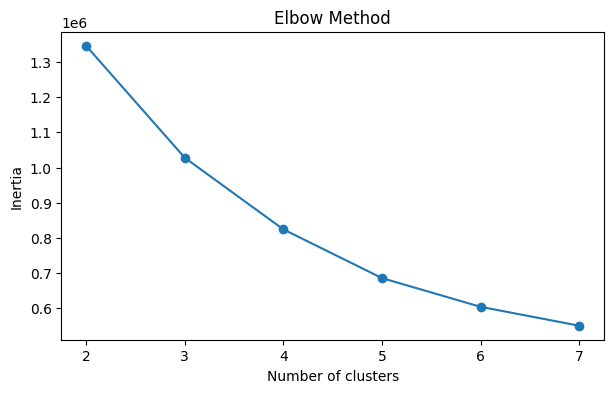

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# 1. copy data
# -----------------------------
df_cluster = df_recipes.copy()

cluster_features = [
    "Calories",
    "FatContent",
    "SugarContent",
    "ProteinContent"
]

# keep usable rows
df_cluster = df_cluster.dropna(subset=cluster_features).copy()

# keep nonnegative values
for col in cluster_features:
    df_cluster = df_cluster[df_cluster[col] >= 0]

# -----------------------------
# 2. remove extreme outliers
#    keep middle 1% to 99%
# -----------------------------
for col in cluster_features:
    lower = df_cluster[col].quantile(0.01)
    upper = df_cluster[col].quantile(0.99)
    df_cluster = df_cluster[(df_cluster[col] >= lower) & (df_cluster[col] <= upper)]

print("Shape after trimming:", df_cluster.shape)

# popularity log
df_cluster["popularity_log"] = np.log1p(df_cluster["popularity_score"].fillna(0))

# -----------------------------
# 3. scale features
# -----------------------------
X = df_cluster[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4. elbow method
# -----------------------------
inertia = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [105]:
# -----------------------------
# 5. run clustering
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print(df_cluster["cluster"].value_counts().sort_index())

cluster
0    306445
1    156805
2     36691
3     39410
Name: count, dtype: int64


In [106]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)

print(centers.round(2))

   Calories  FatContent  SugarContent  ProteinContent
0    203.11        9.00         10.61            5.78
1    470.17       23.96          7.16           27.37
2    723.26       31.12         71.95           10.31
3   1013.05       62.43         12.92           43.25


In [114]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster["pca1"] = X_pca[:, 0]
df_cluster["pca2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.5975015  0.27156968]


In [117]:
print(df_cluster[["pca1", "pca2", "cluster"]].head())

       pca1      pca2  cluster
0 -1.114861  1.032642        0
1  4.336520 -1.123647        3
2 -0.458090  3.140693        2
3  1.138895  0.348479        1
4 -1.425289  0.459053        0


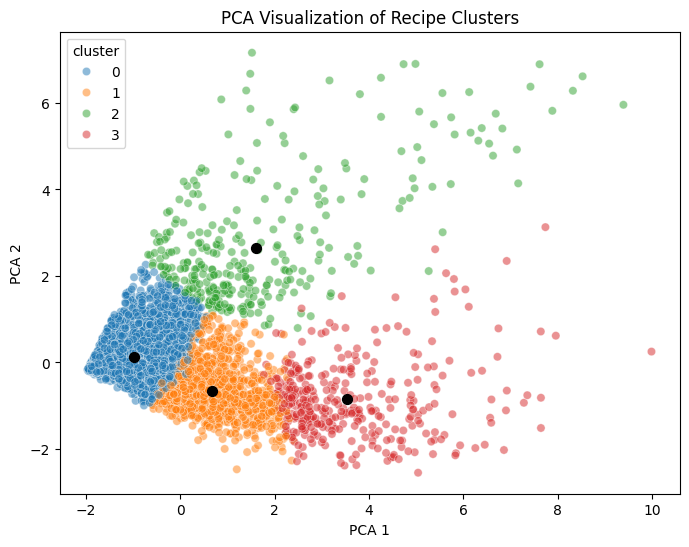

In [126]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_cluster.sample(min(5000, len(df_cluster)), random_state=42),
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    color="black",
    s=50,
    marker="o"
)

plt.title("PCA Visualization of Recipe Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()




In [124]:
cluster_summary = df_cluster.groupby("cluster").agg(
    recipe_count=("RecipeId", "count"),
    avg_calories=("Calories", "mean"),
    avg_fat=("FatContent", "mean"),
    avg_sugar=("SugarContent", "mean"),
    avg_protein=("ProteinContent", "mean"),
    avg_fsa=("FSA_Score", "mean"),
    avg_who=("WHO_Score", "mean"),
    pct_who_healthy=("WHO_Healthy", "mean"),
    pct_fsa_healthy=("FSA_Healthy", "mean"),
    avg_popularity=("popularity_score", "mean"),
    median_popularity=("popularity_score", "median")
).round(2)

cluster_summary

,recipe_count,avg_calories,avg_fat,avg_sugar,avg_protein,avg_fsa,avg_who,pct_who_healthy,pct_fsa_healthy,avg_popularity,median_popularity
cluster,,,,,,,,,,,
0,306445,203.11,9.01,10.60,5.78,5.25,1.69,0.48,0.44,43.45,4.0
1,156805,470.35,23.97,7.16,27.39,12.19,0.95,0.24,0.10,49.84,4.0
2,36691,721.97,31.07,71.85,10.29,22.24,1.38,0.34,0.00,31.53,3.0
3,39410,1013.84,62.47,12.96,43.24,21.34,0.47,0.08,0.00,24.16,4.0


In [125]:
cluster_names = {
    0: "Healthy Light",
    1: "High Protein Meals",
    2: "Sugary Desserts",
    3: "High Fat Indulgent"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)

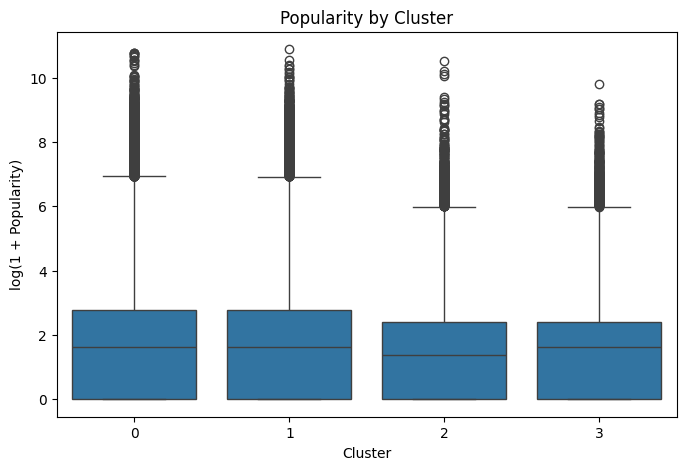

In [127]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster, x="cluster", y="popularity_log")
plt.title("Popularity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("log(1 + Popularity)")
plt.show()

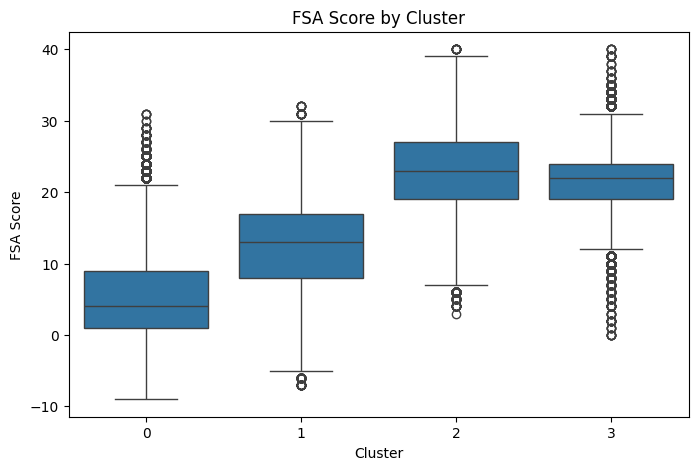

In [128]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster, x="cluster", y="FSA_Score")
plt.title("FSA Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("FSA Score")
plt.show()

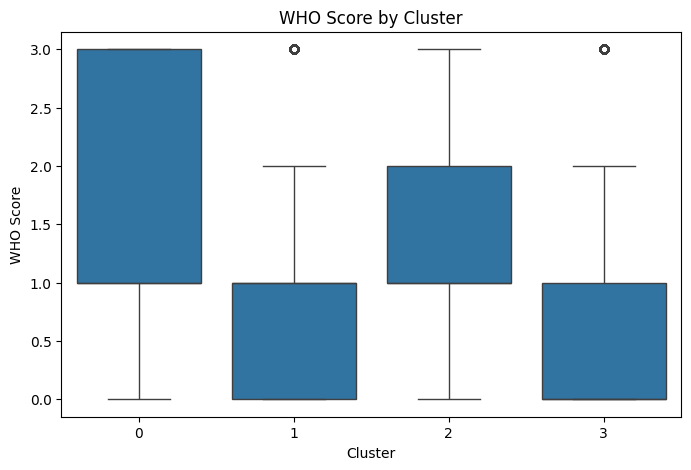

In [129]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster, x="cluster", y="WHO_Score")
plt.title("WHO Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("WHO Score")
plt.show()

In [132]:
import ast

def parse_ingredients(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
    return []


df_cluster["ingredients_final_list"] = df_cluster[
    "ingredients_canonical_final_le_5_replace"
].apply(parse_ingredients)


df_ing = df_cluster[["ID", "cluster", "ingredients_final_list"]].copy()

df_ing = df_ing.explode("ingredients_final_list")

df_ing = df_ing.rename(columns={"ingredients_final_list": "ingredient"})

df_ing["ingredient"] = (
    df_ing["ingredient"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_ing = df_ing[
    (df_ing["ingredient"] != "") &
    (df_ing["ingredient"] != "[]") &
    (df_ing["ingredient"] != "nan")
]


stop_ingredients = [
    "salt", "water", "pepper"
]

df_ing = df_ing[~df_ing["ingredient"].isin(stop_ingredients)]



top_ing_per_cluster = (
    df_ing.groupby(["cluster", "ingredient"])
    .size()
    .reset_index(name="count")
)


top10_ing = (
    top_ing_per_cluster
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)

top10_ing

,cluster,ingredient,count
4537,0,sugar,84460
1490,0,egg,73812
594,0,butter,71034
3269,0,onion,64142
1980,0,garlic,56251
3262,0,olive oil,45053
3060,0,milk,40875
548,0,brown sugar,33482
225,0,baking powder,31104
1689,0,flour,31085


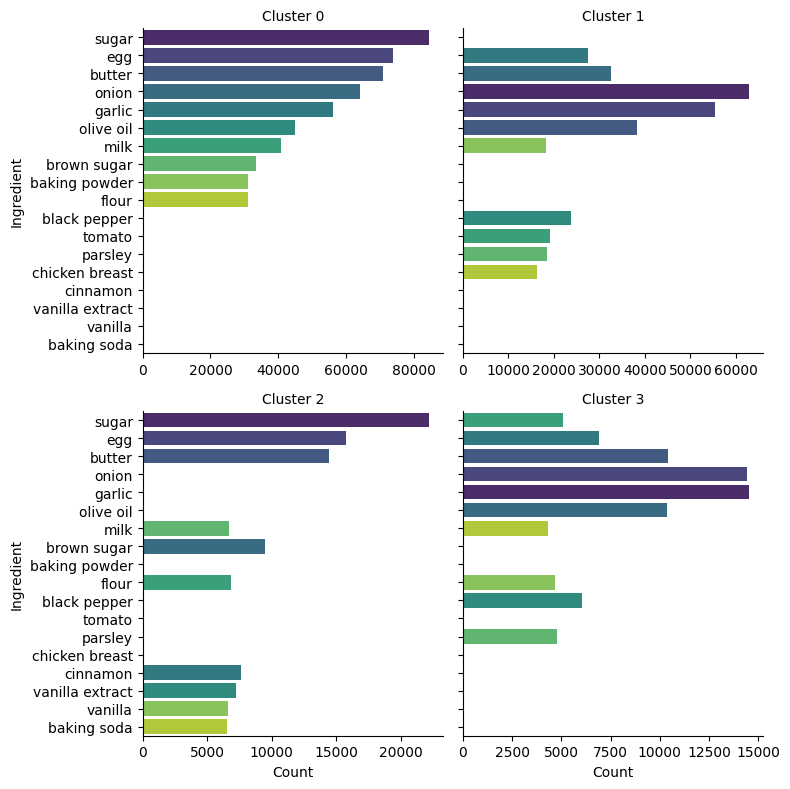

In [133]:
g = sns.FacetGrid(top10_ing, col="cluster", col_wrap=2, sharex=False, height=4)

g.map_dataframe(
    sns.barplot,
    x="count",
    y="ingredient",
    hue="ingredient",
    dodge=False,
    palette="viridis"
)

g.set_titles("Cluster {col_name}")
g.set_axis_labels("Count", "Ingredient")

for ax in g.axes.flatten():
    if ax is not None:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

plt.tight_layout()
plt.show()

In [134]:
representative_recipes = (
    df_cluster.sort_values(["cluster", "popularity_score"], ascending=[True, False])
    .groupby("cluster")
    .head(5)[[
        "cluster", "ID", "Name", "Calories", "FatContent", "SugarContent",
        "ProteinContent", "FSA_Score", "WHO_Score", "popularity_score"
    ]]
)

representative_recipes

,cluster,ID,Name,Calories,FatContent,SugarContent,ProteinContent,FSA_Score,WHO_Score,popularity_score
553356,0,162760_foodrecsys,Fluffy Pancakes,230.3520,8.208835,8.570360,6.370725,11,1,47971.394739
523579,0,56927_foodrecsys,Delicious Ham and Potato Soup,194.8774,10.504740,3.778497,6.083965,8,1,47548.369605
554088,0,17652_foodrecsys,Banana Crumb Muffins,263.2594,8.102324,26.530080,3.199475,13,2,46973.898019
554015,0,20144_foodrecsys,Banana Banana Bread,228.9412,8.848529,14.269150,3.768562,9,1,45916.931489
554152,0,21014_foodrecsys,Good Old Fashioned Pancakes,158.3263,5.921107,3.459945,4.510731,7,1,44390.695049
530084,1,23600_foodrecsys,World's Best Lasagna,448.2073,21.341340,8.601563,29.665170,16,0,53575.129114
535710,1,26317_foodrecsys,Chicken Pot Pie IX,415.2506,24.020090,3.402760,18.658000,14,0,38748.427032
554381,1,50644_foodrecsys,Broiled Tilapia Parmesan,224.3816,12.823910,0.208247,25.371230,4,1,33107.971449
528306,1,16066_foodrecsys,Awesome Slow Cooker Pot Roast,425.7317,23.683520,0.851270,45.631060,15,1,31937.971874
534991,1,8941_foodrecsys,Slow Cooker Chicken and Dumplings,384.6235,18.030630,6.176880,18.105270,15,0,29247.035877


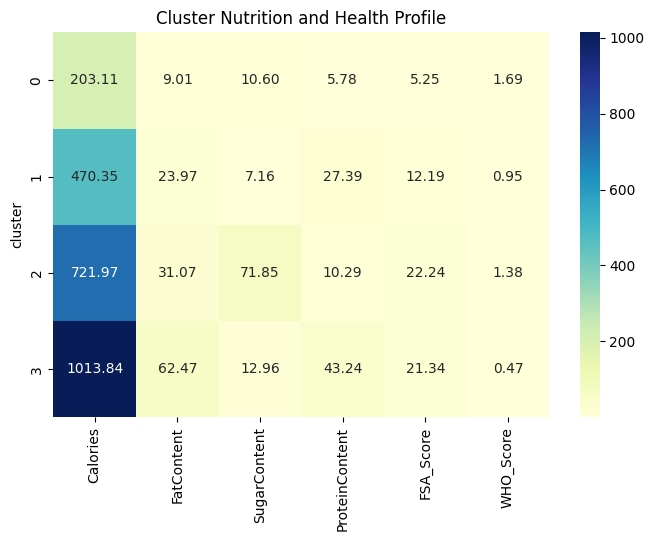

In [135]:
heatmap_df = df_cluster.groupby("cluster")[cluster_features + ["FSA_Score", "WHO_Score"]].mean()

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cluster Nutrition and Health Profile")
plt.show()

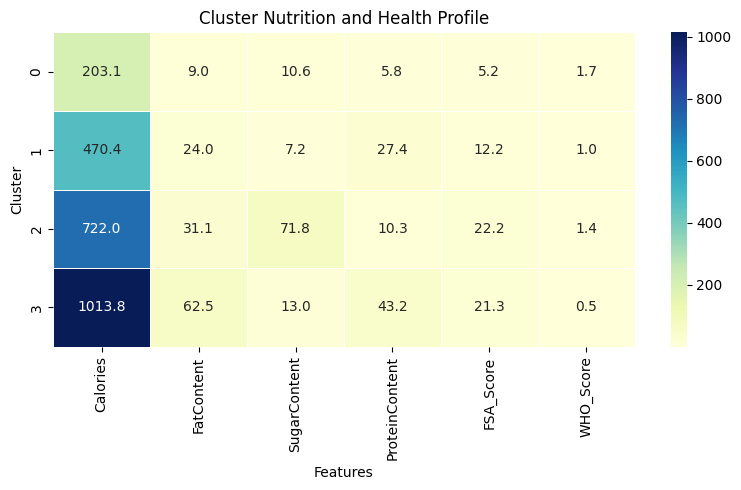

In [137]:
heatmap_df = df_cluster.groupby("cluster")[[
    "Calories",
    "FatContent",
    "SugarContent",
    "ProteinContent",
    "FSA_Score",
    "WHO_Score"
]].mean()

plt.figure(figsize=(8, 5)) 

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cluster Nutrition and Health Profile")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

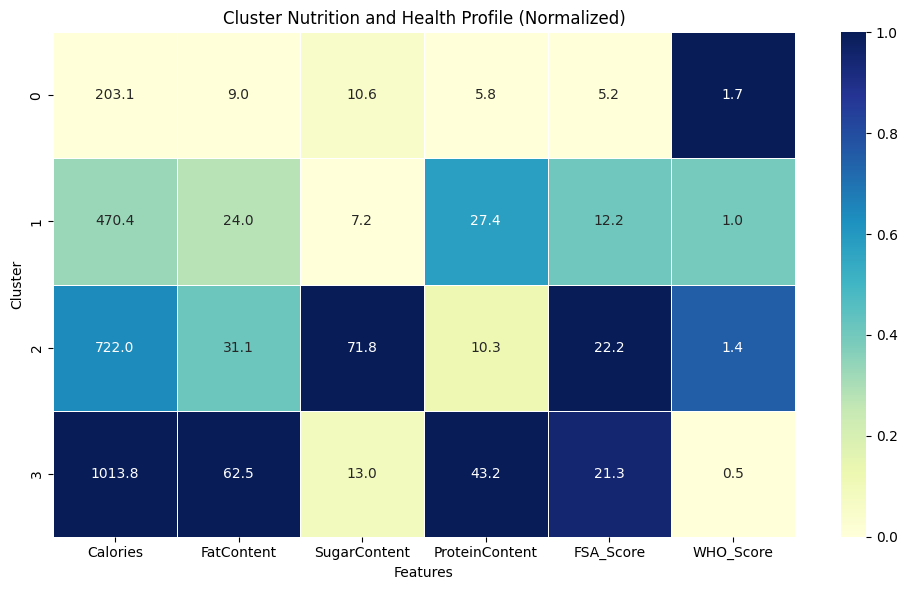

In [141]:
from sklearn.preprocessing import MinMaxScaler

plt.clf()
plt.close('all')
scaler = MinMaxScaler()

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_scaled,
    annot=heatmap_df.round(1),
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cluster Nutrition and Health Profile (Normalized)")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()